In [111]:
from sklearn.datasets import fetch_california_housing

import pandas as pd

X_df = pd.DataFrame(X, columns=housing.feature_names)
y_df = pd.DataFrame(y, columns=['target'])

df = pd.concat([X_df, y_df], axis=1)

display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.396243
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,236.534374
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.937576
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,519.191808
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.561031


In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score



X_train , X_test, y_train,y_test = train_test_split(X, y, test_size=0.2 , random_state = 42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
mae = mean_squared_error(y_test,y_pred)
scores = cross_val_score(model, X, y, cv=5)






In [100]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


Mean Squared Error (MSE): 129.0002
R-squared (R2): 0.9974
Mean Absolute Error (MAE): 129.0002


In [101]:
print(scores)

[0.99796048 0.99816583 0.99772788 0.99785244 0.99795887]


In [113]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)


In [128]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df_moons[['feature_1', 'feature_2']]
y = df_moons['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

moons_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)),
    ('regressor', LinearRegression())
])

moons_pipeline.fit(X_train, y_train)

y_pred = moons_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


print(f"Mean Squared Error (MSE) for make_moons model: {mse:.4f}")
print(f"R-squared (R2) for make_moons model: {r2:.4f}")
print(f"Mean Absolute Error (MAE) for make_moons model: {mae:.4f}")

Mean Squared Error (MSE) for make_moons model: 0.0471
R-squared (R2) for make_moons model: 0.8096
Mean Absolute Error (MAE) for make_moons model: 0.1505


the code under this block is for Week3_Day3 task


In [129]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape)
print(df.isnull().sum())
df.describe().T

(20640, 9)
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


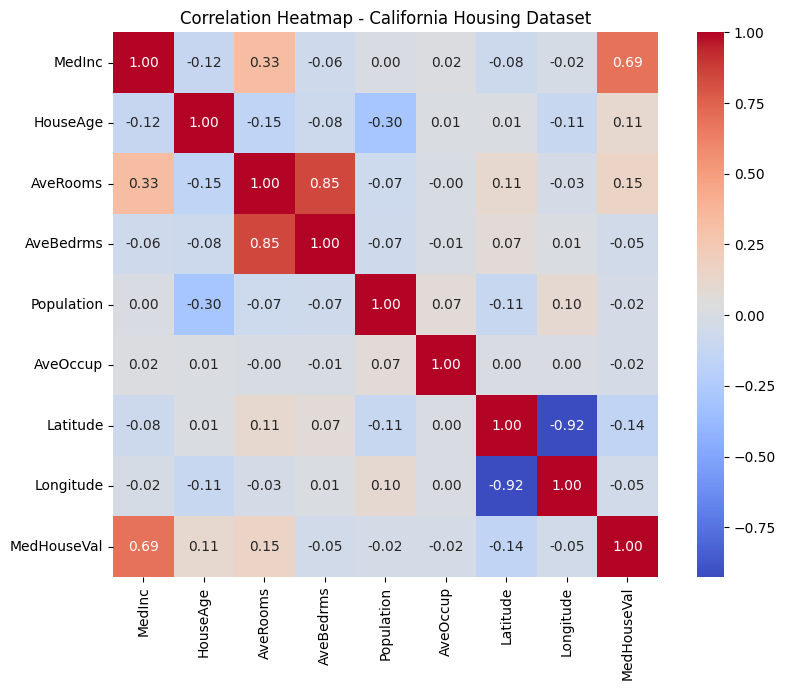

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap - California Housing Dataset")
plt.tight_layout()
plt.show()

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
}

results = []
trained = {}


In [141]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })
    trained[name] = model

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print(results_df)

               Model       MSE      RMSE       MAE        R2
0              Lasso  0.548255  0.740442  0.535326  0.581615
1              Ridge  0.555855  0.745557  0.533193  0.575816
2  Linear Regression  0.555892  0.745581  0.533200  0.575788


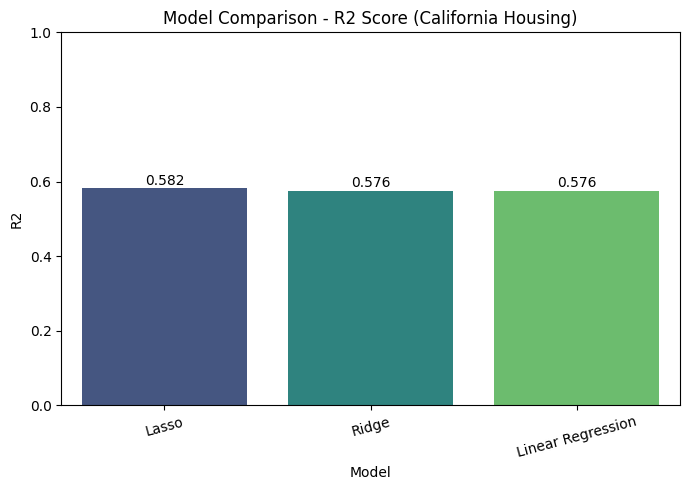

In [142]:
plt.figure(figsize=(7,5))
sns.barplot(data=results_df, x="Model", y="R2", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison - R2 Score (California Housing)")
plt.ylim(0, 1)
for i, v in enumerate(results_df["R2"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [143]:
import joblib
from sklearn.pipeline import Pipeline

best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]
print("Best model:", best_name)

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_model)
])

joblib.dump(pipeline, "best_regression_model.pkl")

Best model: Lasso


['best_regression_model.pkl']

In [139]:
import gradio as gr

pipeline_loaded = joblib.load("best_regression_model.pkl")

feature_names = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
                  "Population", "AveOccup", "Latitude", "Longitude"]

def predict_price(MedInc, HouseAge, AveRooms, AveBedrms,
                   Population, AveOccup, Latitude, Longitude):
    input_df = pd.DataFrame(
        [[MedInc, HouseAge, AveRooms, AveBedrms,
          Population, AveOccup, Latitude, Longitude]],
        columns=feature_names
    )
    prediction = pipeline_loaded.predict(input_df)[0]
    return f"Predicted Median House Value: ${prediction*100000:,.2f}"

demo = gr.Interface(
    fn=predict_price,
    inputs=[gr.Number(label=f) for f in feature_names],
    outputs=gr.Textbox(label="Prediction"),
    title="California Housing Price Predictor",
    description="Enter housing features to predict median house value."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1ef5f9f30cfe25f8e1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
